# Advanced Functional Autograd: `create_graph=True` in Neural Networks
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mitchell-Mirano/sorix/blob/develop/docs/learn/basics/04-functional-autograd.ipynb)
[![Open in GitHub](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/Mitchell-Mirano/sorix/blob/develop/docs/learn/basics/04-functional-autograd.ipynb)
[![Open in Docs](https://img.shields.io/badge/Open%20in-Docs-blue?logo=readthedocs)](https://mitchell-mirano.github.io/sorix/learn/basics/04-functional-autograd/)


In the previous examples, we saw how to differentiate simple mathematical functions. However, the true power of `create_graph=True` lies in **Physics-Informed Neural Networks (PINNs)** and **Gradient Regularization**, where the loss function itself depends on the derivatives of the network.

This tutorial demonstrates how `sorix.autograd.grad` allows backpropagating through the differentiation operation to update neural network weights.


In [1]:
# Uncomment the next line and run this cell to install sorix
#!pip install 'sorix @ git+https://github.com/Mitchell-Mirano/sorix.git@develop'

## 1. Case Study: Gradient Penalty

Imagine we want a neural network $ f(x; \theta) $ to be smooth. One way to enforce this is by adding a penalty to the magnitude of its gradient: 

$$ \mathcal{L}_{penalty} = \left\| \nabla_x f(x; \theta) \right\|^2 $$

To minimize this loss using Gradient Descent, we need to calculate:

$$ \frac{\partial \mathcal{L}_{penalty}}{\partial \theta} = \frac{\partial}{\partial \theta} \left( \frac{\partial f}{\partial x} \right)^2 $$

This is a **higher-order derivative** (gradient of a gradient). Without `create_graph=True`, the first derivative $ \frac{\partial f}{\partial x} $ would be a constant with no connection to the weights $ \theta $, effectively breaking the training loop.


In [2]:
import sorix
import sorix.nn as nn
import sorix.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a simple MLP
class SmoothNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(), # Tanh is smooth and differentiable multiple times
            nn.Linear(16, 1)
        )
    
    def __call__(self, x):
        return self.net(x)

model = SmoothNet()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# Dummy input
x = sorix.tensor([[0.5]], requires_grad=True)

print("Initial weights gradient status before backward:")
# Note: Sorix Linear layer uses .W for weights
print(f"Weight grad is None: {model.net[0].W.grad is None}")


Initial weights gradient status before backward:
Weight grad is None: False


## 2. Differentiating through the Gradient

Here, we compute the gradient of the output with respect to the input and use it as our loss. Note how `create_graph=True` preserves the dependency on the weights.


In [3]:
optimizer.zero_grad()

# 1. Forward Pass
u = model(x)

# 2. Calculate du/dx (gradient w.r.t input)
# IMPORTANT: create_graph=True allows us to call backward() on the result later
du_dx = sorix.grad(u, x, create_graph=True)[0]
print(f"Output u: {u.data.item():.4f}")
print(f"Gradient du/dx: {du_dx.data.item():.4f}")

# 3. Derivative-based Loss (Gradient Penalty)
# We want the function to be flat (du/dx -> 0)
loss = du_dx**2

# 4. Backward Pass
# This computes d(loss)/d(weights), traveling through the du/dx node
loss.backward()

print("\nAfter loss.backward():")
print(f"Weight grad is None: {model.net[0].W.grad is None}")
print(f"Weight grad mean: {np.mean(np.abs(model.net[0].W.grad.data)):.6f}")


Output u: 0.0510
Gradient du/dx: 0.1149

After loss.backward():
Weight grad is None: False
Weight grad mean: 0.032030


### Why this is powerful

In the cell above, the `loss` was computed using the **slope** of the neural network. By calling `loss.backward()`, we updated the weights not to match data points, but to **change the shape of the function itself** (making it flatter).

If we had used `create_graph=False`, the `Weight grad` would have remained `None` (or zero), because the autograd engine would have treated the calculated slope as a fixed number, losing the track of which weights produced that slope.


## 3. Real Example: Learning a Flat Function

Let's train the network for 100 steps where the ONLY goal is to have a gradient of 0 everywhere (i.e., becoming a constant function).


Iter   0 | Gradient Loss: 0.011219
Iter  20 | Gradient Loss: 0.008603
Iter  40 | Gradient Loss: 0.001522
Iter  60 | Gradient Loss: 0.001283
Iter  80 | Gradient Loss: 0.000396
Iter 100 | Gradient Loss: 0.000372


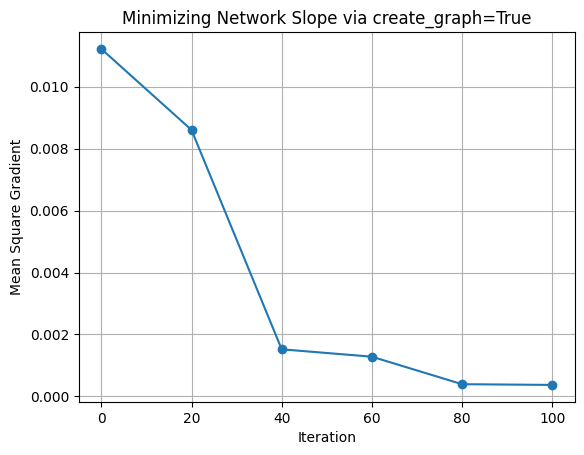

In [4]:
history = []
for i in range(101):
    optimizer.zero_grad()
    
    # Sample random points in [-1, 1]
    x_rand = sorix.tensor(np.random.uniform(-1, 1, (10, 1)), requires_grad=True)
    
    u = model(x_rand)
    # Compute gradients for all points
    du_dx = sorix.grad(u, x_rand, grad_outputs=sorix.ones_like(u),create_graph=True)[0]
    
    # MSE of the gradient vs 0
    loss = (du_dx**2).mean()
    loss.backward()
    optimizer.step()
    
    if i % 20 == 0:
        history.append(loss.item())
        print(f"Iter {i:3d} | Gradient Loss: {loss.item():.6f}")

plt.plot(range(0, 101, 20), history, 'o-')
plt.title("Minimizing Network Slope via create_graph=True")
plt.xlabel("Iteration")
plt.ylabel("Mean Square Gradient")
plt.grid(True)
plt.show()


## Conclusion

- **`create_graph=True`** is required whenever you want to optimize a loss that involves derivatives.
- It enables the "Double Backward" mechanism.
- Without it, Sorix cannot calculate how a derivative changes when the neural network parameters are modified.
